# Laboratorio 4 — Parte 2: modelos de Machine Learning sobre datos geoespaciales
## Lagos Atitlán y Amatitlán — Ejercicios 1 a 10 (entrega completa)

Este notebook continúa el trabajo de `Lab4.ipynb` (Parte I). A partir de los mismos rasters Sentinel-2 L2A (mismos lagos, mismas 11 fechas oficiales por lago), se construye un **conjunto de datos tabular** apto para Machine Learning, se define la **variable respuesta binaria** de alta presencia de cianobacteria, y se seleccionan/justifican las **variables predictoras**.

**Alcance:** los 10 ejercicios de la guía `Laboratorio_4_Parte_2_Datos_Geoespaciales_2026.md` — preparación de datos, variable respuesta, selección de predictores, modelos (Regresión Logística, Random Forest, Gradient Boosting/XGBoost), evaluación, validación espacial y temporal, generalización entre lagos, interpretabilidad (SHAP) y mapas predictivos.


## 0. Dependencias y configuración

Se reutilizan las mismas dependencias de la Parte I. Si el caché de escenas (`data/GIS/lab4_avance/*.tif`) generado en la Parte I ya existe en este equipo, se reutiliza directamente; en caso contrario, se descarga de nuevo desde openEO (requiere autenticación OIDC con cuenta Copernicus).

In [96]:
from datetime import date, timedelta
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import openeo
import pandas as pd
import rasterio
from rasterio.warp import transform as warp_transform

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "GIS" / "lab4_avance"       # cache de escenas de la Parte I (se reutiliza)
OUT_DIR = BASE_DIR / "data" / "GIS" / "lab4_parte2"          # salidas propias de esta Parte II
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

API_URL = "https://openeo.dataspace.copernicus.eu"
COLLECTION = "SENTINEL2_L2A"
BANDS = ["B02", "B03", "B04", "B05", "B08", "SCL"]

# Paso del muestreo sistemático (en píxeles nativos, ~10 m/píxel). Ver justificación en el Ejercicio 1.6.
SAMPLE_STRIDE_PX = 20

print(f"Cache de escenas (Parte I): {DATA_DIR.resolve()}")
print(f"Salidas de esta Parte II: {OUT_DIR.resolve()}")

Cache de escenas (Parte I): /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_avance
Salidas de esta Parte II: /Users/dijan/Documents/U/Data Science/Lab4/data/GIS/lab4_parte2


## 1. Áreas y fechas oficiales (idénticas a la Parte I)

La guía de la Parte II exige usar las mismas fechas que en la Parte I. Se copian exactamente los mismos diccionarios `LAKES` y `OFFICIAL_DATES` de `Lab4.ipynb`.

In [97]:
LAKES = {
    "Atitlan": {
        "west": -91.326256, "east": -91.07151,
        "south": 14.5948, "north": 14.750979,
    },
    "Amatitlan": {
        "west": -90.638065, "east": -90.512924,
        "south": 14.412347, "north": 14.493799,
    },
}

OFFICIAL_DATES = {
    "Atitlan": [
        "2025-01-18", "2025-04-13", "2025-05-13",
        "2025-07-17", "2025-11-21", "2025-12-29",
        "2026-02-12", "2026-03-24", "2026-04-13",
        "2026-04-28", "2026-07-22",
    ],
    "Amatitlan": [
        "2025-01-28", "2025-04-15", "2025-04-28",
        "2025-11-24", "2026-01-08", "2026-02-02",
        "2026-02-07", "2026-03-29", "2026-04-13",
        "2026-04-28", "2026-06-19",
    ],
}

assert set(LAKES) == set(OFFICIAL_DATES)
assert all(len(v) == 11 for v in OFFICIAL_DATES.values())
print("Configuración validada: 2 lagos y 11 fechas oficiales por lago (idénticas a la Parte I).")

Configuración validada: 2 lagos y 11 fechas oficiales por lago (idénticas a la Parte I).


## Ejercicio 1. Preparación de los datos para Machine Learning

### 1.1–1.3 Descarga (o reutilización de caché), lectura de rasters y construcción del conjunto tabular

Cada escena Sentinel-2 se convierte en una tabla de píxeles, aplicando tres filtros antes de aceptar una observación:

1. **Máscara de nubes/nodata (SCL):** se descartan píxeles con `SCL` en {0 nodata, 1 saturado, 3 sombra, 8-10 nubes, 11 nieve/hielo} — igual que en la Parte I.
2. **Máscara de agua (NDWI):** en la Parte I no se encontró un polígono oficial de los lagos en el repositorio, por lo que la geometría de trabajo fue el bounding box (que incluye tierra). Para el Ejercicio 1.3 ("elimine observaciones... fuera de los límites del lago") se necesita algo más preciso que el bounding box: se usa `NDWI > 0` como proxy operativo de "superficie de agua" (McFeeters, 1996, *The use of the Normalized Difference Water Index (NDWI) in the delineation of open water features*, IJRS 17(7), 1425-1432), descartando así los píxeles de tierra dentro del bounding box.
3. **Muestreo sistemático espacial:** se conserva únicamente 1 de cada `SAMPLE_STRIDE_PX` filas/columnas de la grilla nativa (~10 m/píxel). Ver justificación completa en el Ejercicio 1.6.

In [98]:
connection = openeo.connect(API_URL)
connection = connection.authenticate_oidc()
print(f"Conexion autenticada: {API_URL}")

Authenticated using refresh token.
Conexion autenticada: https://openeo.dataspace.copernicus.eu


In [99]:
def scene_path(lake_name, date_text):
    return DATA_DIR / f"{lake_name}_{date_text}.tif"

def download_scene(connection, lake_name, date_text):
    target = scene_path(lake_name, date_text)
    if target.exists() and target.stat().st_size > 0:
        return target
    start = date.fromisoformat(date_text)
    end = start + timedelta(days=1)
    cube = connection.load_collection(
        COLLECTION,
        spatial_extent=LAKES[lake_name],
        temporal_extent=[start.isoformat(), end.isoformat()],
        bands=BANDS,
    )
    job = connection.create_job(
        cube.save_result(format="GTIFF"),
        title=f"Lab4_{lake_name}_{date_text}",
    )
    job.start_and_wait()
    job.download_results(str(target))
    if not target.exists():
        raise FileNotFoundError(f"openEO no creo {target}")
    return target

scene_files = []
for lake_name in LAKES:
    for date_text in OFFICIAL_DATES[lake_name]:
        path = download_scene(connection, lake_name, date_text)
        scene_files.append((lake_name, date_text, path))
print(f"Escenas disponibles: {len(scene_files)}")

Escenas disponibles: 22


In [100]:
def safe_normalized_difference(a, b):
    denominator = a + b
    return np.divide(a - b, denominator, out=np.full_like(a, np.nan, dtype=np.float32), where=denominator != 0)

def build_pixel_table(path, lake_name, date_text, stride=SAMPLE_STRIDE_PX):
    with rasterio.open(path) as src:
        raw = src.read()
        transform = src.transform
        crs = src.crs
        descriptions = list(src.descriptions)
    names = [d.upper() if d else BANDS[i] for i, d in enumerate(descriptions)]
    band_map = {name: raw[i] for i, name in enumerate(names)}
    missing = set(BANDS) - set(band_map)
    if missing:
        raise ValueError(f"Faltan bandas {missing} en {path.name}; descripciones={descriptions}")

    # Se acota a [0, 1]: la reflectancia de superficie no puede ser negativa ni mayor a 1;
    # sin este recorte, denominadores cercanos a 0 en (a-b)/(a+b) producen indices fuera de [-1, 1].
    scale = {
        name: np.clip(band_map[name].astype(np.float32) / 10000.0, 0.0, 1.0)
        for name in BANDS if name != "SCL"
    }
    ndvi = safe_normalized_difference(scale["B08"], scale["B04"])
    ndwi = safe_normalized_difference(scale["B03"], scale["B08"])
    ndci = safe_normalized_difference(scale["B05"], scale["B04"])

    scl = band_map["SCL"]
    clear = ~np.isin(scl, [0, 1, 3, 8, 9, 10, 11])
    water = ndwi > 0.0  # proxy de "dentro del lago" ante ausencia de poligono oficial (McFeeters, 1996)
    valid = clear & water & np.isfinite(ndvi) & np.isfinite(ndwi) & np.isfinite(ndci)

    # Muestreo sistematico: solo se conservan filas/columnas multiplo de `stride`.
    grid_mask = np.zeros(valid.shape, dtype=bool)
    grid_mask[::stride, ::stride] = True
    keep_mask = valid & grid_mask
    rows_idx, cols_idx = np.where(keep_mask)
    if rows_idx.size == 0:
        return pd.DataFrame()

    xs, ys = rasterio.transform.xy(transform, rows_idx, cols_idx, offset="center")
    xs, ys = np.array(xs), np.array(ys)
    lon, lat = warp_transform(crs, "EPSG:4326", xs, ys)

    data = {
        "lake": lake_name,
        "date": pd.Timestamp(date_text),
        "row": rows_idx,
        "col": cols_idx,
        "lon": np.array(lon),
        "lat": np.array(lat),
    }
    for b in ["B02", "B03", "B04", "B05", "B08"]:
        data[b] = scale[b][rows_idx, cols_idx]
    data["NDVI"] = ndvi[rows_idx, cols_idx]
    data["NDWI"] = ndwi[rows_idx, cols_idx]
    data["NDCI"] = ndci[rows_idx, cols_idx]
    return pd.DataFrame(data)

print("Verificacion: la funcion reutiliza la misma logica de indices (NDVI/NDWI/NDCI) y mascara de nubes de la Parte I.")

Verificacion: la funcion reutiliza la misma logica de indices (NDVI/NDWI/NDCI) y mascara de nubes de la Parte I.


In [101]:
frames = []
for lake_name, date_text, path in scene_files:
    frame = build_pixel_table(path, lake_name, date_text)
    frames.append(frame)
    print(f"{lake_name} {date_text}: {len(frame):,} observaciones muestreadas")

ml_dataset = pd.concat(frames, ignore_index=True)
ml_dataset.to_csv(OUT_DIR / "ml_dataset_bruto.csv", index=False)
print(f"\nTotal de observaciones: {len(ml_dataset):,}")
ml_dataset.head()

Atitlan 2025-01-18: 1,864 observaciones muestreadas
Atitlan 2025-04-13: 3,076 observaciones muestreadas
Atitlan 2025-05-13: 3,090 observaciones muestreadas
Atitlan 2025-07-17: 3,063 observaciones muestreadas
Atitlan 2025-11-21: 3,042 observaciones muestreadas
Atitlan 2025-12-29: 3,034 observaciones muestreadas
Atitlan 2026-02-12: 2,864 observaciones muestreadas
Atitlan 2026-03-24: 3,070 observaciones muestreadas
Atitlan 2026-04-13: 3,063 observaciones muestreadas
Atitlan 2026-04-28: 3,067 observaciones muestreadas
Atitlan 2026-07-22: 3,052 observaciones muestreadas
Amatitlan 2025-01-28: 393 observaciones muestreadas
Amatitlan 2025-04-15: 382 observaciones muestreadas
Amatitlan 2025-04-28: 374 observaciones muestreadas
Amatitlan 2025-11-24: 388 observaciones muestreadas
Amatitlan 2026-01-08: 365 observaciones muestreadas
Amatitlan 2026-02-02: 351 observaciones muestreadas
Amatitlan 2026-02-07: 390 observaciones muestreadas
Amatitlan 2026-03-29: 395 observaciones muestreadas
Amatitlan 20

,lake,date,row,col,lon,lat,B02,B03,B04,B05,B08,NDVI,NDWI,NDCI
0,Atitlan,2025-01-18,60,1740,-91.164735,14.746331,0.0106,0.0096,0.0004,0.0002,0.0000,-1.000000,1.000000,-0.333333
1,Atitlan,2025-01-18,80,1660,-91.172179,14.744583,0.0124,0.0114,0.0017,0.0001,0.0026,0.209302,0.628571,-0.888889
2,Atitlan,2025-01-18,100,1640,-91.174051,14.742790,0.0119,0.0093,0.0006,0.0019,0.0000,-1.000000,1.000000,0.520000
3,Atitlan,2025-01-18,120,1360,-91.200067,14.741186,0.0132,0.0102,0.0013,0.0000,0.0059,0.638889,0.267081,-1.000000
4,Atitlan,2025-01-18,120,1440,-91.192638,14.741128,0.0168,0.0131,0.0022,0.0002,0.0014,-0.222222,0.806897,-0.833333


### 1.4 Resumen del conjunto de datos

Número total de observaciones, observaciones por lago y por fecha, tipo de cada variable, y porcentaje de valores faltantes.

In [102]:
print(f"Observaciones totales: {len(ml_dataset):,}\n")

print("Observaciones por lago:")
display(ml_dataset["lake"].value_counts().to_frame("n_observaciones"))

print("\nObservaciones por lago y fecha:")
display(ml_dataset.groupby(["lake", "date"]).size().to_frame("n_observaciones"))

print("\nTipo de cada variable:")
display(ml_dataset.dtypes.to_frame("dtype"))

print("\nPorcentaje de valores faltantes por variable:")
missing_pct = (100 * ml_dataset.isna().mean()).round(3)
display(missing_pct.to_frame("pct_faltante"))

Observaciones totales: 36,442

Observaciones por lago:


,n_observaciones
lake,
Atitlan,32285
Amatitlan,4157



Observaciones por lago y fecha:


n_observaciones
lake      date                       
Amatitlan 2025-01-28              393
          2025-04-15              382
          2025-04-28              374
          2025-11-24              388
          2026-01-08              365
          2026-02-02              351
          2026-02-07              390
          2026-03-29              395
          2026-04-13              395
          2026-04-28              319
          2026-06-19              405
Atitlan   2025-01-18             1864
          2025-04-13             3076
          2025-05-13             3090
          2025-07-17             3063
          2025-11-21             3042
          2025-12-29             3034
          2026-02-12             2864
          2026-03-24             3070
          2026-04-13             3063
          2026-04-28             3067
          2026-07-22             3052


Tipo de cada variable:


,dtype
lake,object
date,datetime64[s]
row,int64
col,int64
lon,float64
lat,float64
B02,float32
B03,float32
B04,float32
B05,float32



Porcentaje de valores faltantes por variable:


,pct_faltante
lake,0.0
date,0.0
row,0.0
col,0.0
lon,0.0
lat,0.0
B02,0.0
B03,0.0
B04,0.0
B05,0.0


### 1.5 Análisis exploratorio de las variables

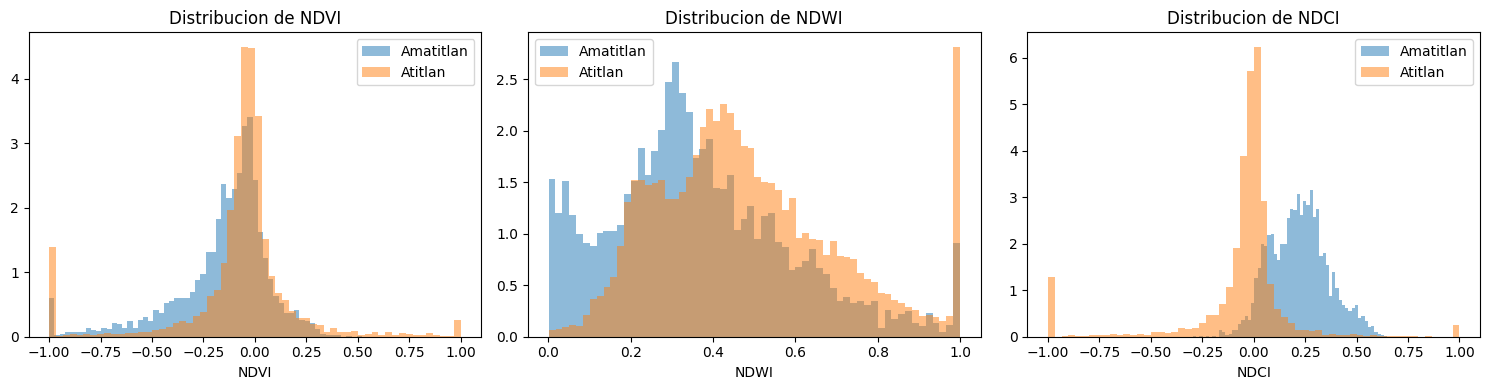

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["NDVI", "NDWI", "NDCI"]):
    for lake_name, group in ml_dataset.groupby("lake"):
        ax.hist(group[col], bins=60, alpha=0.5, label=lake_name, density=True)
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)
    ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_histogramas_indices.png", dpi=150, bbox_inches="tight")
plt.show()

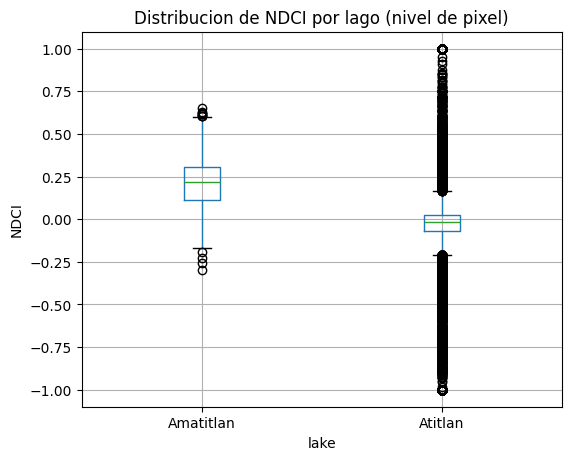

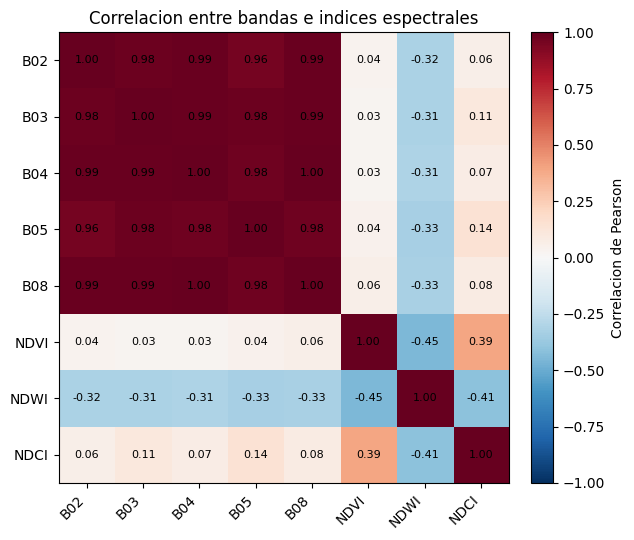

In [104]:
fig, ax = plt.subplots(figsize=(6, 5))
ml_dataset.boxplot(column="NDCI", by="lake", ax=ax)
ax.set_title("Distribucion de NDCI por lago (nivel de pixel)")
ax.set_ylabel("NDCI")
plt.suptitle("")
fig.savefig(OUT_DIR / "eda_boxplot_ndci_lago.png", dpi=150, bbox_inches="tight")
plt.show()

corr_cols = ["B02", "B03", "B04", "B05", "B08", "NDVI", "NDWI", "NDCI"]
corr = ml_dataset[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlacion de Pearson")
ax.set_title("Correlacion entre bandas e indices espectrales")
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_correlacion_bandas.png", dpi=150, bbox_inches="tight")
plt.show()

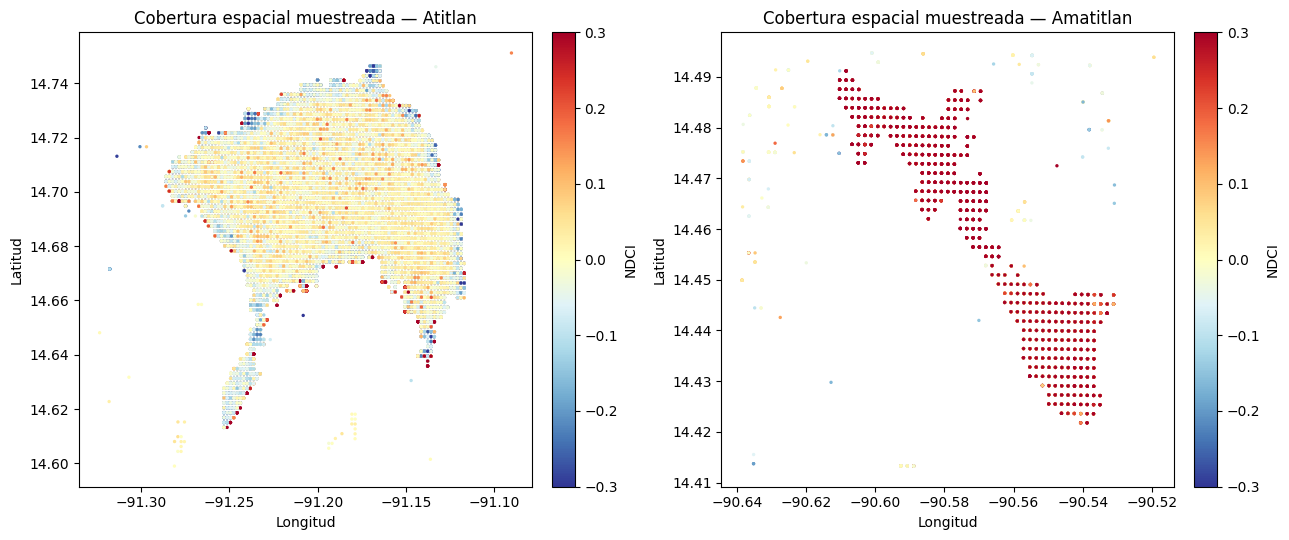

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, lake_name in zip(axes, LAKES):
    sub = ml_dataset[ml_dataset["lake"] == lake_name]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["NDCI"], cmap="RdYlBu_r", s=2, vmin=-0.3, vmax=0.3)
    ax.set_title(f"Cobertura espacial muestreada — {lake_name}")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="NDCI")
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_cobertura_espacial.png", dpi=150, bbox_inches="tight")
plt.show()

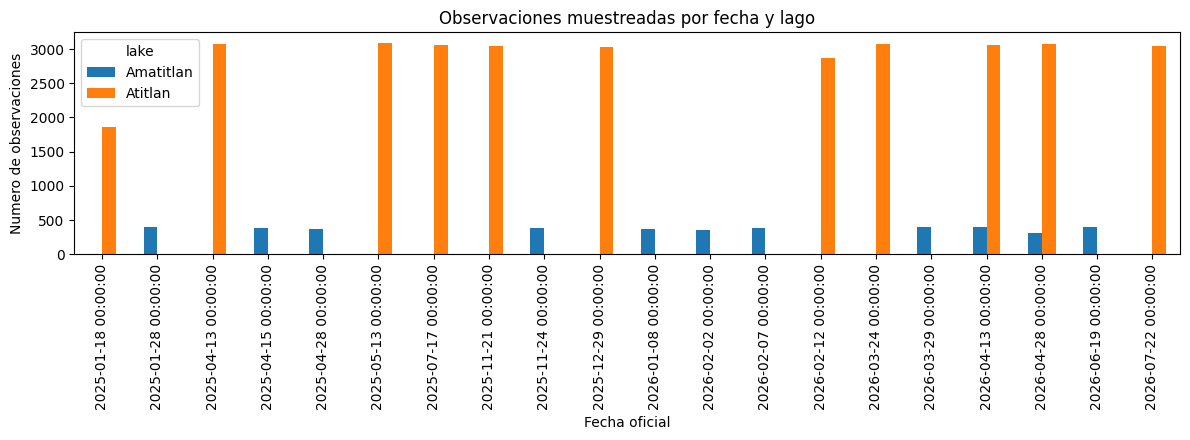

In [106]:
fig, ax = plt.subplots(figsize=(12, 4.5))
counts = ml_dataset.groupby(["date", "lake"]).size().unstack("lake")
counts.plot(kind="bar", ax=ax)
ax.set_ylabel("Numero de observaciones")
ax.set_xlabel("Fecha oficial")
ax.set_title("Observaciones muestreadas por fecha y lago")
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_observaciones_por_fecha.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.6 Decisiones tomadas durante la preparación y limpieza de los datos

- **Reutilización del caché de la Parte I:** las escenas Sentinel-2 (GeoTIFF) descargadas para `Lab4.ipynb` se reutilizan directamente (`download_scene` solo descarga si el archivo no existe), evitando volver a consultar la API y garantizando exactamente las mismas 22 escenas (2 lagos × 11 fechas oficiales).

- **Máscara de nubes (SCL):** se excluyen píxeles nodata, saturados, con sombra de nube, nube (media/alta probabilidad, cirros) y nieve/hielo, replicando el criterio de la Parte I.

- **Máscara de agua (NDWI > 0) en lugar del bounding box:** como no existe un GeoJSON oficial de los lagos en el repositorio, la Parte I usó el bounding box como respaldo, el cual incluye tierra alrededor del lago. Para esta Parte II, donde cada fila debe ser una "observación geográfica válida dentro de alguno de los lagos" (Ejercicio 1.1), esto es insuficiente. Se añade un filtro `NDWI > 0` (umbral estándar de McFeeters, 1996, para distinguir agua de superficies no acuáticas) que excluye la mayoría de píxeles de tierra dentro del bounding box. **Limitación conocida:** este es un proxy, no un polígono batimétrico real; en la orilla puede haber algo de error de inclusión/exclusión. Si en el futuro se consigue el GeoJSON oficial de los lagos, debería preferirse sobre este proxy.

- **Escalamiento de reflectancia:** las bandas Sentinel-2 L2A se dividen entre 10000 para obtener reflectancia de superficie en el rango [0, 1], igual que en la Parte I.

- **Sistema de coordenadas:** cada escena se descarga en su CRS proyectado nativo (UTM de la zona correspondiente); las coordenadas de cada observación se reproyectan a `EPSG:4326` (longitud/latitud) para tener un sistema común e interpretable entre fechas y lagos. Para el Ejercicio 6 (validación espacial) se reproyectará a `EPSG:32615` según lo exige la guía.

- **Muestreo sistemático espacial (`SAMPLE_STRIDE_PX = 20`, ~200 m de espaciamiento):** usar cada píxel válido a 10 m de resolución nativa generaría decenas de millones de observaciones (aprox. 49.6 M para Atitlán y 13.3 M para Amatitlán solo considerando píxeles válidos, sin contar el filtro de agua adicional), lo cual es computacionalmente inviable para entrenar e interpretar modelos (incluido SHAP en el Ejercicio 8) y, más importante, **viola el supuesto de observaciones independientes**: píxeles vecinos a 10 m están masivamente autocorrelacionados espacialmente (el mismo parche de agua), por lo que tratarlos como observaciones i.i.d. infla artificialmente el desempeño de una partición aleatoria. Se aplica un muestreo sistemático (cuadrícula regular) con el mismo paso físico para ambos lagos, de modo que la densidad de observaciones por km² sea comparable entre lagos y el número total de filas por lago refleje su tamaño real. Este espaciamiento (~200 m) también deja múltiples observaciones dentro de cada bloque espacial de ~1 km × 1 km que se usará en el Ejercicio 6, lo cual es necesario para que esa validación espacial tenga sentido. El valor de `SAMPLE_STRIDE_PX` queda como parámetro ajustable si se requiere un dataset más grande o más pequeño.

## Ejercicio 2. Construcción de la variable respuesta

### 2.1–2.2 Variable binaria y justificación del punto de corte

La variable respuesta se basa en el **NDCI** (`(B05-B04)/(B05+B04)`), el índice espectral de clorofila-a/cianobacteria calculado en la Parte I. Para justificar el punto de corte se combinan tres fuentes:

1. **Mishra, S., & Mishra, D. R. (2012).** *Normalized Difference Chlorophyll Index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters.* Remote Sensing of Environment, 117, 394–406. Este trabajo introdujo el NDCI usando reflectancias en ~665 nm y ~705 nm (equivalentes a las bandas Sentinel-2 B04 y B05 usadas aquí) y demostró una relación cuadrática/cúbica robusta (R² ≈ 0.9–0.95) entre NDCI y la concentración real de clorofila-a medida en campo, en un rango de 1 a 60 mg/m³.

2. **Sentinel Hub — Custom script "Cyanobacteria / Chlorophyll-a (NDCI, L1C)"** (https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/), la misma fuente que originó el umbral exploratorio de 0.20 usado en la Parte I. Este script opera con la misma fórmula de NDCI y la convierte a clorofila-a (µg/L) mediante el modelo cúbico calibrado:

   `chl_a = 826.57·NDCI³ − 176.43·NDCI² + 19·NDCI + 4.071`

3. **Chorus, I., & Bartram, J. (Eds.). (1999).** *Toxic Cyanobacteria in Water: A guide to their public health consequences, monitoring and management.* World Health Organization. Y su actualización más reciente sobre ambientes recreativos (OMS, guías de "niveles de alerta"), que definen umbrales operativos de riesgo por floración de cianobacterias en términos de clorofila-a: el **Nivel de Alerta 1** (probabilidad de efectos adversos "baja a moderada", inicio de vigilancia) corresponde aproximadamente a **10–12 µg/L de clorofila-a** con dominancia de cianobacterias (valor de 12 µg/L / 3 mm³/L de biovolumen usado en el marco de niveles por tramos más reciente de la OMS para aguas recreativas); el **Nivel de Alerta 2** (riesgo moderado a alto, posible formación de espuma tóxica) corresponde a ~50 µg/L.

Usando la fórmula cúbica del script de Sentinel Hub, se resuelve numéricamente qué valor de NDCI produce una clorofila-a equivalente de 12 µg/L (Nivel de Alerta 1 de la OMS), y se compara contra el umbral exploratorio de 0.20 ya usado en la Parte I.

In [107]:
def ndci_to_chla(ndci):
    """Modelo cubico NDCI -> clorofila-a (ug/L), calibrado por el script de cianobacteria de Sentinel Hub,
    basado en Mishra & Mishra (2012)."""
    return 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071

# NDCI equivalente al Nivel de Alerta 1 de la OMS (~12 ug/L de clorofila-a).
poly_coeffs = [826.57, -176.43, 19, 4.071 - 12.0]
roots = np.roots(poly_coeffs)
real_roots = roots[np.isreal(roots)].real
ndci_who_alert1 = float(real_roots[(real_roots > 0) & (real_roots < 1)][0])
print(f"NDCI equivalente a 12 ug/L de clorofila-a (Nivel de Alerta 1, OMS): {ndci_who_alert1:.3f}")

NDCI_HIGH_THRESHOLD = 0.20
chla_en_umbral = ndci_to_chla(NDCI_HIGH_THRESHOLD)
print(f"Umbral exploratorio usado (Parte I y este avance): NDCI >= {NDCI_HIGH_THRESHOLD}")
print(f"Clorofila-a equivalente en ese umbral (modelo cubico): {chla_en_umbral:.2f} ug/L")
print(
    "Interpretacion: el umbral NDCI=0.20 es MAS CONSERVADOR (precautorio) que el Nivel de Alerta 1 de la OMS "
    f"(equivalente a NDCI~{ndci_who_alert1:.2f}); detecta floraciones antes de alcanzar el nivel de alerta formal, "
    "lo cual es apropiado para un sistema de monitoreo temprano orientado a ambientalistas."
)

ml_dataset["chla_eq_ugL"] = ndci_to_chla(ml_dataset["NDCI"])
ml_dataset["alta_cianobacteria"] = (ml_dataset["NDCI"] >= NDCI_HIGH_THRESHOLD).astype(int)
ml_dataset[["NDCI", "chla_eq_ugL", "alta_cianobacteria"]].describe()

NDCI equivalente a 12 ug/L de clorofila-a (Nivel de Alerta 1, OMS): 0.264
Umbral exploratorio usado (Parte I y este avance): NDCI >= 0.2
Clorofila-a equivalente en ese umbral (modelo cubico): 7.43 ug/L
Interpretacion: el umbral NDCI=0.20 es MAS CONSERVADOR (precautorio) que el Nivel de Alerta 1 de la OMS (equivalente a NDCI~0.26); detecta floraciones antes de alcanzar el nivel de alerta formal, lo cual es apropiado para un sistema de monitoreo temprano orientado a ambientalistas.


,NDCI,chla_eq_ugL,alta_cianobacteria
count,36442.000000,36442.000000,36442.000000
mean,-0.027305,-36.203682,0.100681
std,0.268434,211.207352,0.300909
min,-1.000000,-1017.929016,0.000000
25%,-0.056604,2.280344,0.000000
50%,-0.004695,3.977823,0.000000
75%,0.047619,4.664947,0.000000
max,1.000000,673.210999,1.000000


### 2.3 Distribución de la variable respuesta

Distribucion global:


,proporcion
alta_cianobacteria,
baja/ausente (0),0.899319
alta (1),0.100681



Proporcion de 'alta_cianobacteria' por lago:


,proporcion_alta
lake,
Amatitlan,0.563146
Atitlan,0.041134



Proporcion de 'alta_cianobacteria' por lago y fecha:


proporcion_alta
lake      date                       
Amatitlan 2025-01-28         0.796438
          2025-04-15         0.287958
          2025-04-28         0.427807
          2025-11-24         0.358247
          2026-01-08         0.800000
          2026-02-02         0.156695
          2026-02-07         0.387179
          2026-03-29         0.673418
          2026-04-13         0.896203
          2026-04-28         0.457680
          2026-06-19         0.876543
Atitlan   2025-01-18         0.223712
          2025-04-13         0.009103
          2025-05-13         0.007767
          2025-07-17         0.014691
          2025-11-21         0.128863
          2025-12-29         0.054713
          2026-02-12         0.052374
          2026-03-24         0.008143
          2026-04-13         0.008162
          2026-04-28         0.007825
          2026-07-22         0.010485

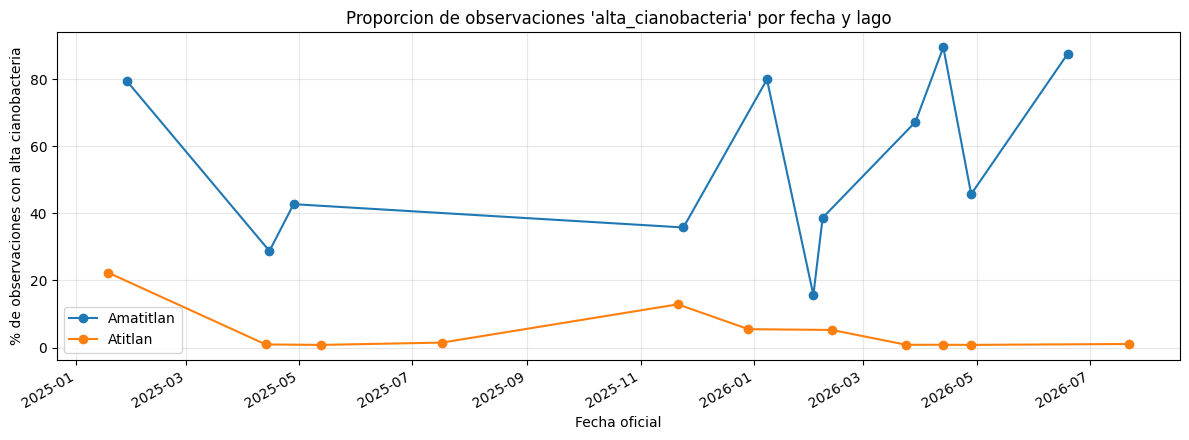

In [108]:
overall = ml_dataset["alta_cianobacteria"].value_counts(normalize=True).rename("proporcion").to_frame()
overall.index = overall.index.map({0: "baja/ausente (0)", 1: "alta (1)"})
print("Distribucion global:")
display(overall)

por_lago = ml_dataset.groupby("lake")["alta_cianobacteria"].mean().to_frame("proporcion_alta")
print("\nProporcion de 'alta_cianobacteria' por lago:")
display(por_lago)

por_fecha = ml_dataset.groupby(["lake", "date"])["alta_cianobacteria"].mean().to_frame("proporcion_alta")
print("\nProporcion de 'alta_cianobacteria' por lago y fecha:")
display(por_fecha)

fig, ax = plt.subplots(figsize=(12, 4.5))
for lake_name, group in ml_dataset.groupby("lake"):
    serie = group.groupby("date")["alta_cianobacteria"].mean().sort_index()
    ax.plot(serie.index, 100 * serie.values, marker="o", label=lake_name)
ax.set_ylabel("% de observaciones con alta cianobacteria")
ax.set_xlabel("Fecha oficial")
ax.set_title("Proporcion de observaciones 'alta_cianobacteria' por fecha y lago")
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT_DIR / "distribucion_variable_respuesta.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Desbalance de clases

Se cuantifica la razón entre clases y se discuten las consecuencias para el entrenamiento/evaluación de los modelos.

In [109]:
class_counts = ml_dataset["alta_cianobacteria"].value_counts().sort_index()
ratio = class_counts[1] / class_counts[0] if 0 in class_counts.index and class_counts[0] > 0 else float("nan")
print(f"Clase 0 (baja/ausente): {class_counts.get(0, 0):,} observaciones")
print(f"Clase 1 (alta): {class_counts.get(1, 0):,} observaciones")
print(f"Razon clase1:clase0 = {ratio:.2f} : 1")
print(f"Proporcion de la clase minoritaria: {100 * min(class_counts) / class_counts.sum():.1f}%")

Clase 0 (baja/ausente): 32,773 observaciones
Clase 1 (alta): 3,669 observaciones
Razon clase1:clase0 = 0.11 : 1
Proporcion de la clase minoritaria: 10.1%


**Consecuencias del desbalance (a evaluar formalmente con la proporción obtenida arriba):**

- Si una clase domina claramente, un modelo trivial que siempre prediga la clase mayoritaria puede alcanzar un **Accuracy** engañosamente alto sin tener ninguna capacidad real de detectar floraciones — por eso el Ejercicio 5 exige reportar también Precision, Recall, F1 y ROC-AUC, no solo Accuracy.
- El **Recall de la clase "alta cianobacteria"** es la métrica más sensible al desbalance: con pocas observaciones positivas, el modelo tiende a "aprender" a favorecer la clase mayoritaria y a subestimar la minoritaria (más falsos negativos), que es justamente el error más costoso desde el punto de vista ambiental (no detectar una floración real).
- Implicaciones para el entrenamiento (a aplicar en el Ejercicio 4): usar `class_weight="balanced"` (Regresión Logística, Random Forest) o `scale_pos_weight` (XGBoost/Gradient Boosting), y validar con **partición estratificada** para que el conjunto de prueba conserve la misma proporción de clases que el conjunto completo.
- Implicaciones para la validación espacial (Ejercicio 6) y entre lagos (Ejercicio 7): si el desbalance difiere entre lagos o zonas espaciales, la comparación de métricas entre esos subconjuntos debe hacerse con cuidado (una métrica sensible al desbalance, como Accuracy, puede variar solo porque cambió la proporción de clases, no porque el modelo generalice peor).

### 2.5 Variables que no pueden usarse como predictoras (fuga de información)

La variable respuesta `alta_cianobacteria` se construye directamente a partir de `NDCI`, y `NDCI = (B05 − B04) / (B05 + B04)`. Siguiendo la instrucción de la guía ("una variable utilizada directa o indirectamente para construir la variable respuesta no deberá incluirse como predictora"):

| Variable | Motivo de exclusión |
|---|---|
| `NDCI` | Fuga **directa**: es exactamente la variable con la que se definió el umbral y la clase. |
| `chla_eq_ugL` | Fuga **directa**: es una transformación determinista 1-a-1 de `NDCI` (permitiría reconstruir `NDCI` y, con ello, la etiqueta, de forma casi perfecta). |
| `B05` | Fuga **indirecta**: junto con `B04`, determina algebraicamente el valor exacto de `NDCI`. Dejarla como predictora permitiría a un modelo reconstruir `NDCI` (y la etiqueta) casi exactamente, sin aprender ninguna relación ambiental real. |
| `B04` | Misma razón que `B05`: interviene directamente en la fórmula de `NDCI`. |

**Nota sobre NDVI:** `NDVI = (B08 − B04) / (B08 + B04)` también usa `B04`, la misma banda que interviene en `NDCI`. Estrictamente, esto introduce una fuga *parcial* (no una reconstrucción exacta de `NDCI`, porque `NDVI` no contiene información equivalente a `B05`). Se decide **conservar `NDVI` como predictora** porque (a) la guía la exige explícitamente como variable mínima del conjunto de datos, y (b) a diferencia de `B04`/`B05`, no permite recuperar el valor exacto de `NDCI` ni de la etiqueta — el riesgo de fuga "trivial" (reconstrucción exacta) queda eliminado al excluir `B04` y `B05`, que es el riesgo real que la instrucción busca evitar.

**Conjunto final excluido como predictor por fuga de información:** `NDCI`, `chla_eq_ugL`, `B04`, `B05`.